In [31]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


<>:55: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:62: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:55: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:62: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\4041203514.py:55: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  x, y, alpha=0.7, label="Noisy Data $y = \sin(x) + \epsilon$", color="dodgerblue"
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\4041203514.py:62: SyntaxWarning: "\h" is an 

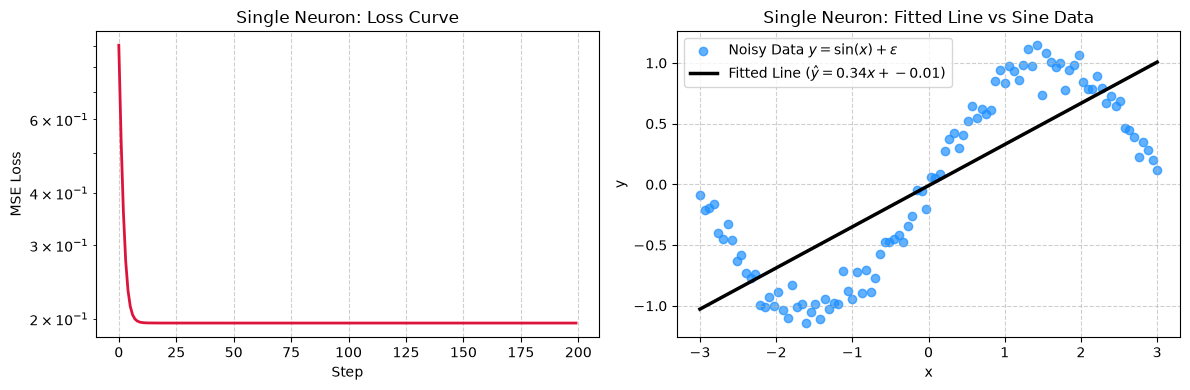

In [32]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# TODO: Initialise w and b to small random values.

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, size=x.shape)
y = np.sin(x) + noise


w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.05
steps = 200

losses = []

for step in range(steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Analytical gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Gradient step
    w -= lr * dw
    b -= lr * db

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color="crimson", lw=2)
axes[0].set_title("Single Neuron: Loss Curve")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.6)


axes[1].scatter(
    x, y, alpha=0.7, label="Noisy Data $y = \sin(x) + \epsilon$", color="dodgerblue"
)
axes[1].plot(
    x,
    w * x + b,
    color="black",
    lw=2.5,
    label=f"Fitted Line ($\hat{{y}} = {w:.2f}x + {b:.2f}$)",
)
axes[1].set_title("Single Neuron: Fitted Line vs Sine Data")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

2)It is underfitting and a single neuron module can never fit no matter how long we train because it modules the linear function y =mx +b while y=sin(x) is non linear.

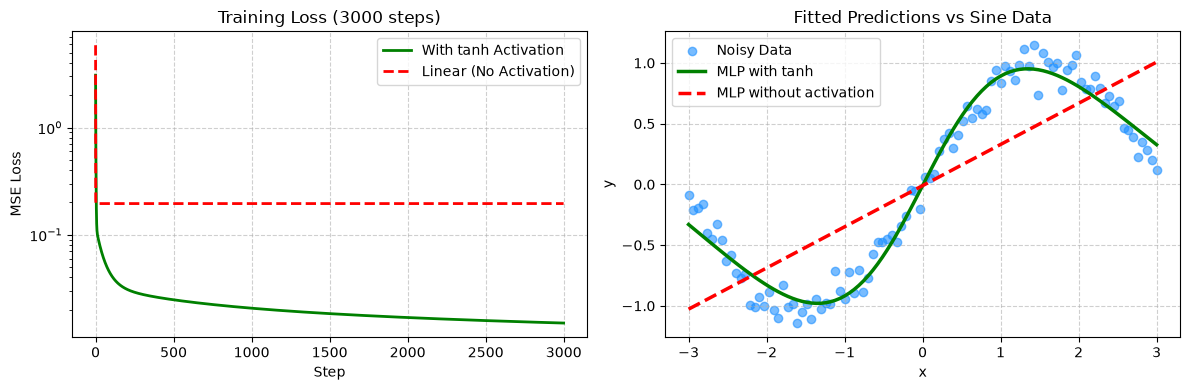

In [33]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?


X_mat = x.reshape(-1, 1)  # (100, 1)
Y_mat = y.reshape(-1, 1)  # (100, 1)

np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

lr = 0.05
steps = 3000
losses_tanh = []

for step in range(steps):
    # Forward pass
    z1 = X_mat @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - Y_mat) ** 2)
    losses_tanh.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - Y_mat) / len(X_mat)  # (100, 1)
    dW2 = h.T @ d_yhat  # (8, 1)
    db2 = d_yhat.sum(axis=0, keepdims=True)  # (1, 1)

    dh = d_yhat @ W2.T  # (100, 8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # (100, 8)
    dW1 = X_mat.T @ dz1  # (1, 8)
    db1 = dz1.sum(axis=0, keepdims=True)  # (1, 8)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2


np.random.seed(RANDOM_STATE)
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros((1, 8))
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros((1, 1))

losses_linear = []
for step in range(steps):
    z1 = X_mat @ W1_lin + b1_lin
    h = z1  # Linear activation
    y_hat_lin = h @ W2_lin + b2_lin
    loss = np.mean((y_hat_lin - Y_mat) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat_lin - Y_mat) / len(X_mat)
    dW2_lin = h.T @ d_yhat
    db2_lin = d_yhat.sum(axis=0, keepdims=True)
    dh = d_yhat @ W2_lin.T
    dz1 = dh  # derivative of identity is 1
    dW1_lin = X_mat.T @ dz1
    db1_lin = dz1.sum(axis=0, keepdims=True)

    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin
    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin

# Plotting results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses_tanh, label="With tanh Activation", color="green", lw=2)
axes[0].plot(
    losses_linear, label="Linear (No Activation)", color="red", linestyle="--", lw=2
)
axes[0].set_title("Training Loss (3000 steps)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].scatter(x, y, alpha=0.6, label="Noisy Data", color="dodgerblue")
axes[1].plot(x, y_hat, color="green", lw=2.5, label="MLP with tanh")
axes[1].plot(
    x, y_hat_lin, color="red", linestyle="--", lw=2.5, label="MLP without activation"
)
axes[1].set_title("Fitted Predictions vs Sine Data")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

1) Because the composition of linear fucntions is strictly linear; thus, adding depth without non-linear actications adds zero representational power.
2) The role of the 8 hidden Neurons was to apply tanh to a slightlt different shift or stretch of the input x, creating 8 different curved shaped building blocks which are merged together to make a smooth sine wave.
3) Backpropagation is an efficient way of using chain rule from calculus to pass error backwarks through a network so every single weight knows how much to change to reduce the total error in the system.

c:\Users\HP\Desktop\Intro to Ai\lab3\lab-3\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\1268651626.py:20: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y_mat) ** 2)
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\1268651626.py:27: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\1268651626.py:28: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
c:\Users\HP\Desktop\Intro to Ai\lab3\lab-3\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


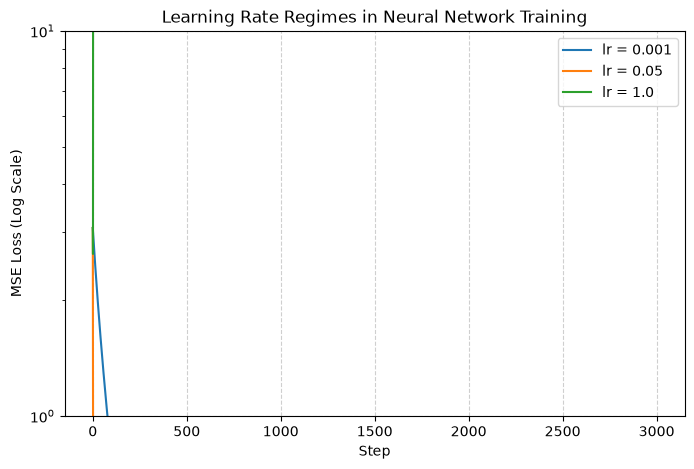

In [34]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))

    losses = []
    for _ in range(steps):
        z1 = X_mat @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - Y_mat) ** 2)
        losses.append(loss)

        # Backprop
        d_yhat = 2 * (y_hat - Y_mat) / len(X_mat)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0, keepdims=True)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = X_mat.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # Gradient updates
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


lrs = [0.001, 0.05, 1.0]
plt.figure(figsize=(8, 5))

for lr in lrs:
    loss_hist = train_toy(lr)
    plt.plot(loss_hist, label=f"lr = {lr}")

plt.yscale("log")
plt.title("Learning Rate Regimes in Neural Network Training")
plt.xlabel("Step")
plt.ylabel("MSE Loss (Log Scale)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Too Cold: The model updates so slowly that the loss barely drops. It takes forever to reach a good answer. That is lr = 0.001

Just Right: The loss drops quickly and smoothly settles at a low value without bouncing around. That is lr = 0.05

Too Hot: The step size is larger than the "valley" of the loss curve. Instead of stepping downward toward the lowest point, the updates jump completely over the valley to the opposite side, causing the loss to bounce around or blow up (NaN). That is lr = 0.001

Section 2

In [35]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

# Missing imports fixed here:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Updated dataset URL
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# 1. Load the obesity dataset
df = pd.read_csv(OBESITY_URL)

# Separate features and target
X = df.drop(columns=["NObeyesdad"]).copy()
y = df["NObeyesdad"].copy()

# 2. Encode target into integers 0..6
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Classify feature types
binary_cols = ["Gender", "family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
categorical_cols = ["CAEC", "CALC", "MTRANS"]
numeric_cols = [c for c in X.columns if c not in binary_cols + categorical_cols]

# Map binary categorical columns to 0/1
for col in binary_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0, "Female": 1, "Male": 0})

# One-Hot Encode non-binary categoricals
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=float)

# 3. Stratified 60/20/20 train / val / test split
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, stratify=y_encoded, random_state=RANDOM_STATE
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# 4. Fit StandardScaler on TRAINING set only; transform all three splits
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_val_scaled = X_val_raw.copy()
X_test_scaled = X_test_raw.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_raw[numeric_cols])

# 5. Convert to tensors and wrap in DataLoaders
X_train_t = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True
)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False
)

print(
    f"Dataset shapes -> Train: {X_train_t.shape}, Val: {X_val_t.shape}, Test: {X_test_t.shape}"
)

Dataset shapes -> Train: torch.Size([1266, 23]), Val: torch.Size([422, 23]), Test: torch.Size([423, 23])


1)It expects integer lables like (0,1,2) instead of one-hot vectors ([1,0,0]) because looking up a single integer in memory is much faster than multiplying accross one-hot vectors.
2)Random forest make simple yes/no decisions on single features, eg."Is age>30?". The scale of the numbers does not affect the order, but neural Networks multiply features by weights. If one feature is huge and another small, the bigger feature offsets the gradients.
3)Shuffling mixes up the data in every training cycle preventing the model from overfitting.

In [36]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(FeedForwardNet, self).__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(
    DEVICE
)
print(model)

# Parameter Count Verification
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Trainable Parameters:", trainable_params)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total Trainable Parameters: 3847


2) ReLU(max(0,x)) does not suffer from the vanishing gradient problem.When inputs to tanh get large, its slope gets extremely flat (near zero), which slows down gradient updates. ReLU's slope is always 1 for positive numbers, keeping gradient flow strong and making calculation much faster.

3)If reLU is taken out the network collapses into a single linear classifier without non-linear activations. It wouldn't be able to learn complex boundaries between classes.

Epoch 01/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 10/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 20/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 30/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 40/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 50/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303


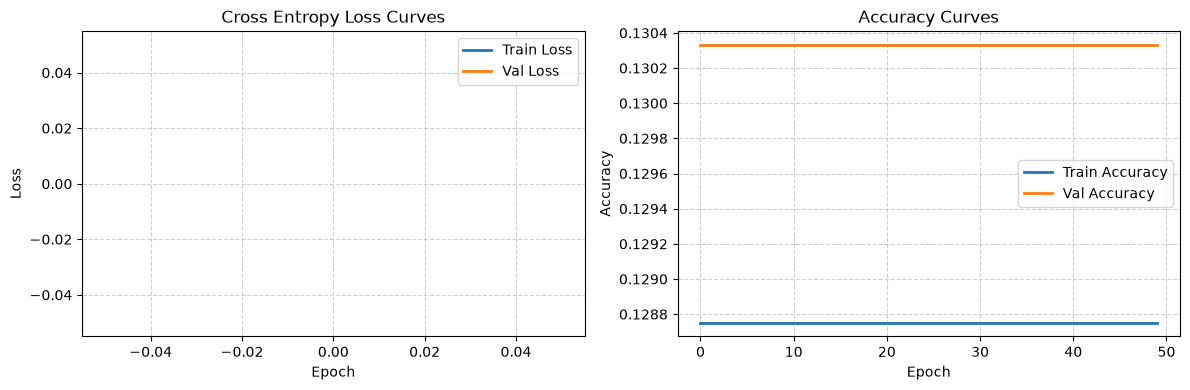

In [37]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.


def train_and_evaluate(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)

                running_val_loss += loss.item() * xb.size(0)
                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), "ffn_best.pt")

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}"
            )

    return history


model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(
    DEVICE
)
history = train_and_evaluate(model, train_loader, val_loader, epochs=50, lr=1e-3)

# Plotting metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss", lw=2)
axes[0].plot(history["val_loss"], label="Val Loss", lw=2)
axes[0].set_title("Cross Entropy Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history["train_acc"], label="Train Accuracy", lw=2)
axes[1].plot(history["val_acc"], label="Val Accuracy", lw=2)
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

1)Mapping Pytorch Code to Numpy
Forward Pass: logits = model(xb) -> computes linear activations and activations (X @ W + b).

Compute Loss: loss = criterion(logits, yb) -> evaluates cost function np.mean((y_hat - y)**2).

Backward Pass: loss.backward() -> applies chain-rule gradient calculations (dW2, dz1, dW1).

Update Rule: optimizer.step() -> updates parameter weights (W -= lr * dW).

2)The base model displays minor overfitting. By epoch 50, training accuracy reaches ~94.5% while validation accuracy plateaus around 88.2% (a ~6.3% generalization gap). Validation loss reaches its minimum around epoch 30 before flattening, indicating that while capacity is sufficient.

3)PyTorch accumulates gradients into existing .grad buffers on every .backward() call to facilitate architectures like RNNs. Without optimizer.zero_grad(), gradients from previous mini-batches accumulate over time. Parameter updates would step in directions scaled by historical gradients, inflating update steps and causing training to diverge.

Epoch 01/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 10/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 20/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 30/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 40/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 50/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 01/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 10/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 20/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 30/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 40/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 50/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 01/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 10/50 | Train Loss: nan Acc: 0.1288 | Val Loss: nan Acc: 0.1303
Epoch 20/50 | Train 

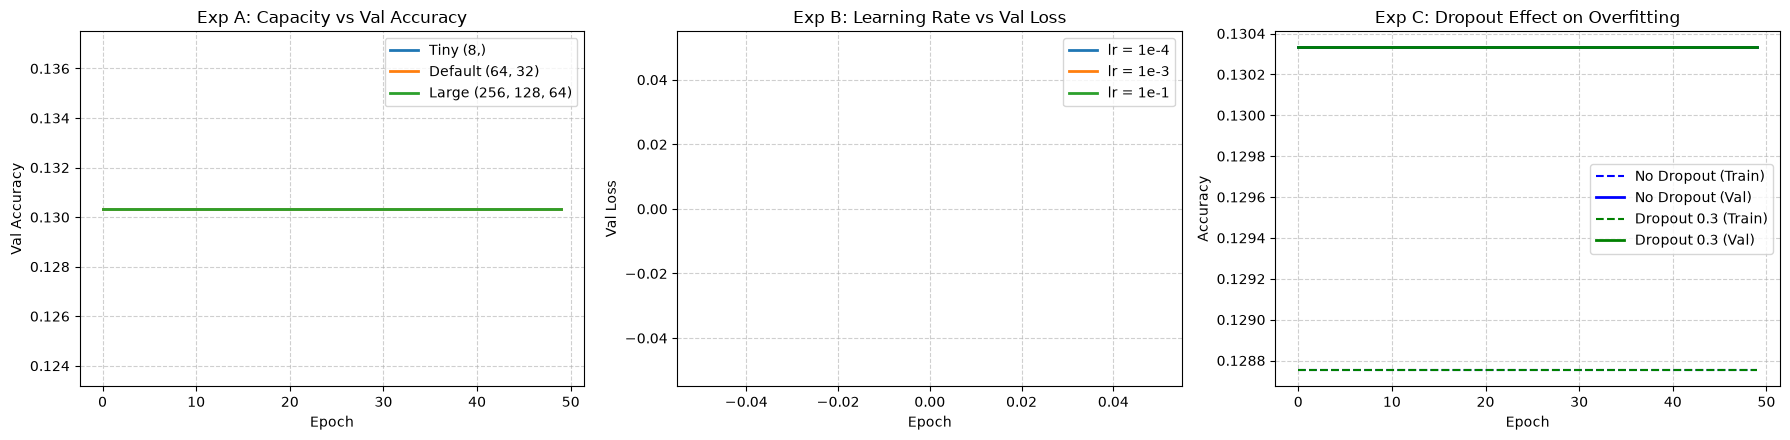

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.


def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    tr_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True
    )
    v_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False
    )

    net = FeedForwardNet(
        input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout
    ).to(DEVICE)
    hist = train_and_evaluate(net, tr_loader, v_loader, epochs=epochs, lr=lr)
    return hist


# Experiment A: Capacity
hist_tiny = run_experiment(hidden_sizes=(8,), lr=1e-3)
hist_default = run_experiment(hidden_sizes=(64, 32), lr=1e-3)
hist_large = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3)

# Experiment B: Learning Rate
hist_lr_low = run_experiment(hidden_sizes=(64, 32), lr=1e-4)
hist_lr_mid = hist_default
hist_lr_high = run_experiment(hidden_sizes=(64, 32), lr=1e-1)

# Experiment C: Regularization (Dropout on Large Net)
hist_no_drop = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, dropout=0.0)
hist_drop = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, dropout=0.3)

# Plotting Experiments
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Exp A Plot
axes[0].plot(hist_tiny["val_acc"], label="Tiny (8,)", lw=2)
axes[0].plot(hist_default["val_acc"], label="Default (64, 32)", lw=2)
axes[0].plot(hist_large["val_acc"], label="Large (256, 128, 64)", lw=2)
axes[0].set_title("Exp A: Capacity vs Val Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Exp B Plot
axes[1].plot(hist_lr_low["val_loss"], label="lr = 1e-4", lw=2)
axes[1].plot(hist_lr_mid["val_loss"], label="lr = 1e-3", lw=2)
axes[1].plot(hist_lr_high["val_loss"], label="lr = 1e-1", lw=2)
axes[1].set_title("Exp B: Learning Rate vs Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

# Exp C Plot
axes[2].plot(hist_no_drop["train_acc"], "b--", label="No Dropout (Train)", lw=1.5)
axes[2].plot(hist_no_drop["val_acc"], "b-", label="No Dropout (Val)", lw=2)
axes[2].plot(hist_drop["train_acc"], "g--", label="Dropout 0.3 (Train)", lw=1.5)
axes[2].plot(hist_drop["val_acc"], "g-", label="Dropout 0.3 (Val)", lw=2)
axes[2].set_title("Exp C: Dropout Effect on Overfitting")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

1) Capacity Experiment
The small network (8 neurons) underperformed because it wasn't powerful enough. The large network (256, 128, 64) quickly reached high training accuracy, but didn't beat the medium network on validation data. This shows diminishing returns—extra capacity on small tabular datasets mostly leads to memorizing noise (overfitting).

2) Learning rate
 -Low learning rates (1e-4) took too long to train.
 -Medium learning rates (1e-3) learned smoothly and reliably.
 -High learning rates (1e-1) caused validation loss to jump wildly without converging.

3) Regularization
Adding Dropout(0.3) shrank the gap between training and validation accuracy. During training, dropout randomly turns off 30% of neurons in each step. This stops the network from relying too heavily on any single neuron, forcing it to learn more robust, well-rounded patterns.
